# Job Market Intelligence — Application Pipeline Analysis

**Author:** Xiao Long  
**Updated:** 2026-05-07  

End-to-end analysis of my DS/DA job search pipeline: status breakdown, application cadence, rejection patterns, location distribution, and LinkedIn outreach tracking. Data sourced from a SQLite database populated from real applications.

**Dataset:** 307 tracked applications (Feb–May 2026)

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime, date

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

conn = sqlite3.connect('../data/jobs.db')

df = pd.read_sql_query("""
    SELECT
        j.id, j.date_found, j.company, j.role, j.location, j.remote,
        a.date_applied, a.app_status, a.linkedin_contact, a.linkedin_status
    FROM jobs j
    JOIN applications a ON j.id = a.job_id
""", conn)

conn.close()

df['date_applied'] = pd.to_datetime(df['date_applied'])
df['week'] = df['date_applied'].dt.to_period('W')
df['month'] = df['date_applied'].dt.to_period('M')

print(f"Total applications: {len(df)}")
df.head()

# Records where an actual decision was made (applied/rejected/interview/skip/discarded/evaluated)
df_actioned = df[df['app_status'] != 'unknown'].copy()
print(f"Actioned records: {len(df_actioned)} | Pipeline (unprocessed): {(df['app_status'] == 'unknown').sum()}")

Total applications: 307
Actioned records: 172 | Pipeline (unprocessed): 135


## 1. Overall Status Breakdown

Note: 135 pipeline (unprocessed) entries excluded from chart — see summary for full count.

Actioned applications only (excl. pipeline):
            Count  Pct (%)
app_status                
applied       136     79.1
rejected       20     11.6
skip            9      5.2
interview       3      1.7
discarded       3      1.7
evaluated       1      0.6


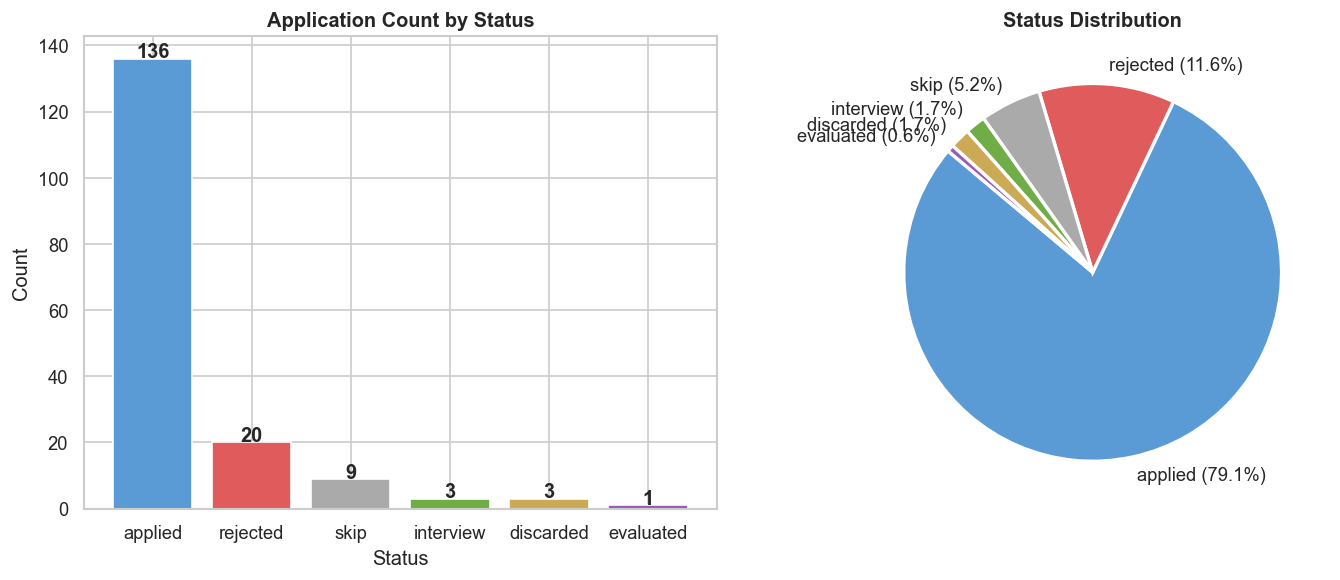

In [2]:
print("Note: {} pipeline (unprocessed) entries excluded from chart — see summary for full count.".format((df['app_status'] == 'unknown').sum()))
print()
status_counts = df_actioned['app_status'].value_counts()
status_pct = (status_counts / len(df_actioned) * 100).round(1)

summary = pd.DataFrame({'Count': status_counts, 'Pct (%)': status_pct})
print("Actioned applications only (excl. pipeline):")
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {
    'applied':   '#5B9BD5',
    'rejected':  '#E05C5C',
    'interview': '#70AD47',
    'skip':      '#AAAAAA',
    'discarded': '#CCAA55',
    'evaluated': '#9B59B6',
    'unknown':   '#DDDDDD',
}
# Rename 'unknown' in display labels only (these are unprocessed pipeline entries)
display_labels = ['pipeline (pending)' if s == 'unknown' else s for s in status_counts.index]
bar_colors = [colors.get(s, '#999') for s in status_counts.index]

axes[0].bar(display_labels, status_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Application Count by Status', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

pie_labels = ["{} ({:.1f}%)".format(dl, p) for dl, p in zip(display_labels, status_pct)]
pie_colors = [colors.get(s, '#999') for s in status_counts.index]
axes[1].pie(
    status_counts.values,
    labels=pie_labels,
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Status Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/fig1_status_breakdown.png', bbox_inches='tight')
plt.show()


## 2. Application Cadence Over Time

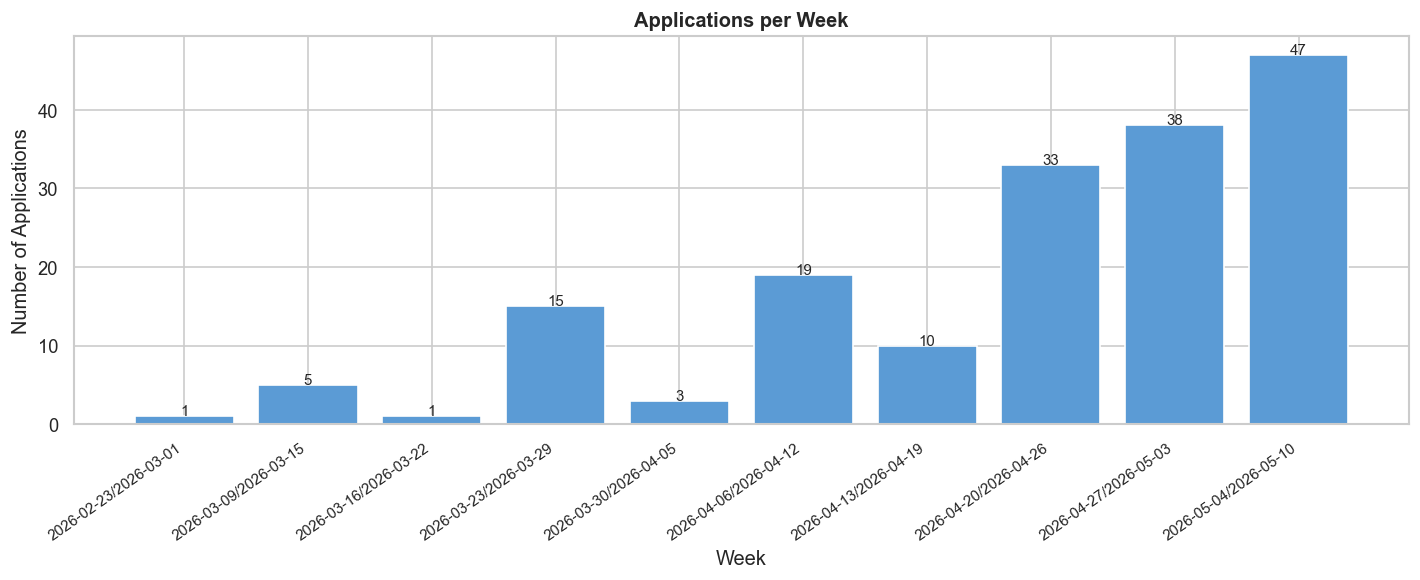

Peak week: 2026-05-04/2026-05-10 (47 apps)


In [3]:
weekly = df.groupby('week').size().reset_index(name='apps')
weekly['week_str'] = weekly['week'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(weekly)), weekly['apps'], color='#5B9BD5', edgecolor='white')
ax.set_xticks(range(len(weekly)))
ax.set_xticklabels(weekly['week_str'], rotation=35, ha='right', fontsize=9)
ax.set_title('Applications per Week', fontweight='bold')
ax.set_ylabel('Number of Applications')
ax.set_xlabel('Week')
for i, v in enumerate(weekly['apps']):
    ax.text(i, v + 0.1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/fig2_weekly_cadence.png', bbox_inches='tight')
plt.show()
print(f"Peak week: {weekly.loc[weekly['apps'].idxmax(), 'week_str']} ({weekly['apps'].max()} apps)")

## 3. Top Companies by Application Volume

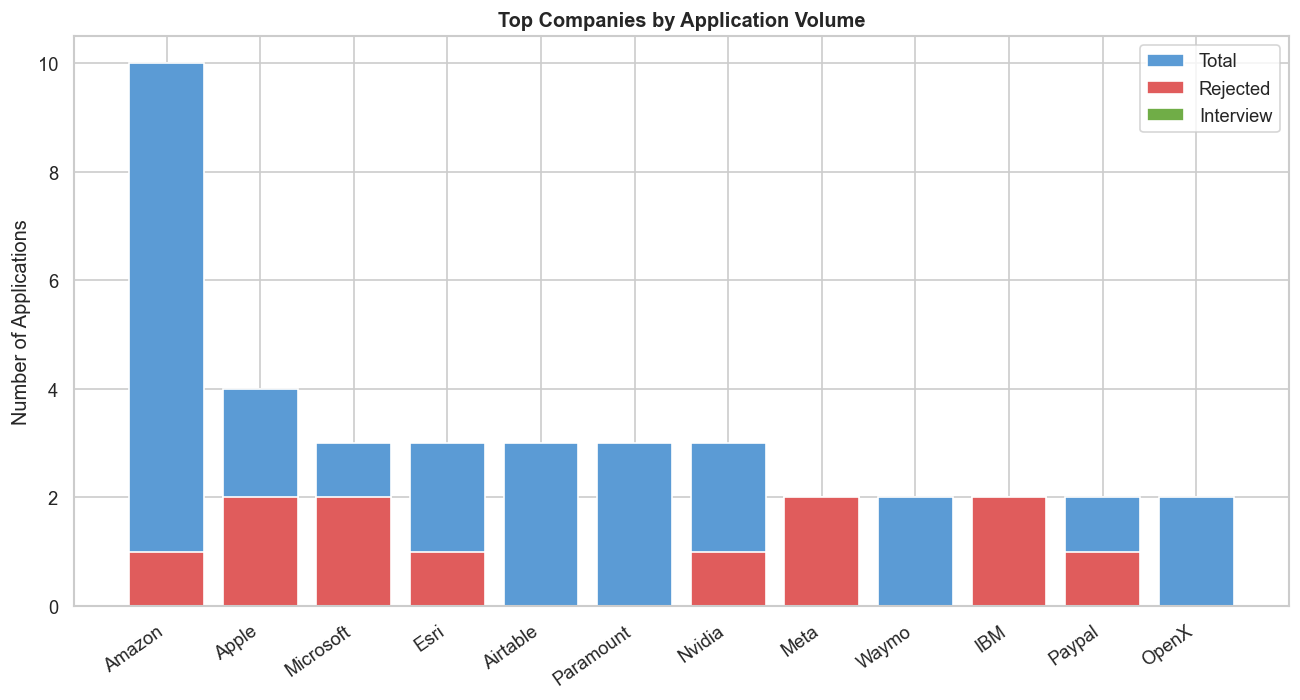

In [4]:
company_stats = df_actioned.groupby('company').agg(
    total=('id', 'count'),
    rejected=('app_status', lambda x: (x == 'rejected').sum()),
    interview=('app_status', lambda x: (x == 'interview').sum())
).sort_values('total', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(company_stats))
bars = ax.bar(x, company_stats['total'], color='#5B9BD5', edgecolor='white', label='Total')
ax.bar(x, company_stats['rejected'], color='#E05C5C', edgecolor='white', label='Rejected')
ax.bar(x, company_stats['interview'], color='#70AD47', edgecolor='white', label='Interview')

ax.set_xticks(x)
ax.set_xticklabels(company_stats.index, rotation=35, ha='right')
ax.set_title('Top Companies by Application Volume', fontweight='bold')
ax.set_ylabel('Number of Applications')
ax.legend()

plt.tight_layout()
plt.savefig('../data/fig3_top_companies.png', bbox_inches='tight')
plt.show()

## 4. Location Distribution

/var/folders/yb/g054kwkj3nz1cwp2wwhjy7mc0000gn/T/ipykernel_72429/2627169182.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


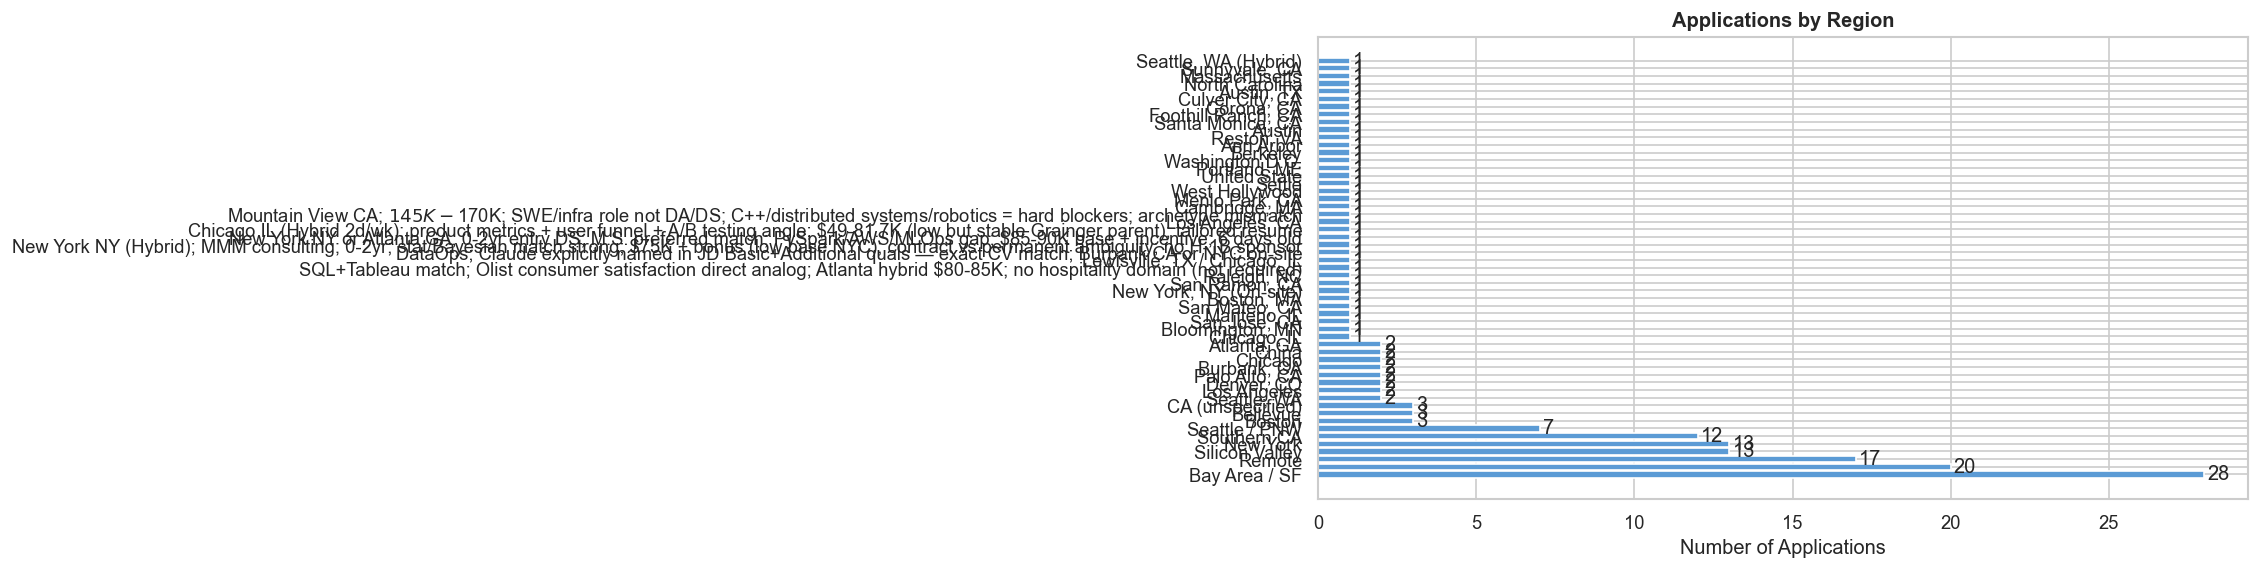

In [5]:
def normalize_location(loc):
    if pd.isna(loc): return 'Unknown'
    loc = loc.strip()
    if 'remote' in loc.lower() or loc == 'Atlanta/remote': return 'Remote'
    if loc in ['San Francisco', 'San Francisco Bay Area', 'Santa Monica',
               'San Bruno', 'Redwood City']: return 'Bay Area / SF'
    if loc in ['San Diego', 'San Diego, CA', 'Orange County HQ',
               'Rancho Cucamonga']: return 'Southern CA'
    if loc in ['Santa Clara', 'Cupertino', 'Mountain View',
               'San Jose']: return 'Silicon Valley'
    if loc in ['California']: return 'CA (unspecified)'
    if loc in ['Redmond', 'Seattle', 'Seattle']: return 'Seattle / PNW'
    if loc in ['Los Angeles']: return 'Los Angeles'
    if loc in ['Cambridge']: return 'Boston'
    if loc in ['Beijing']: return 'China'
    return loc

df_actioned['region'] = df_actioned['location'].apply(normalize_location)
region_counts = df_actioned['region'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(region_counts.index, region_counts.values, color='#5B9BD5', edgecolor='white')
ax.set_title('Applications by Region', fontweight='bold')
ax.set_xlabel('Number of Applications')
for i, v in enumerate(region_counts.values):
    ax.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.savefig('../data/fig4_location_distribution.png', bbox_inches='tight')
plt.show()

## 5. LinkedIn Outreach Tracking

In [6]:
outreach = df[(df['linkedin_contact'].notna()) & (df['linkedin_contact'] != '')].copy()
replied = (outreach['linkedin_status'] == 'replied').sum()
reply_rate = replied / len(outreach) * 100 if len(outreach) > 0 else 0.0

print("Total outreach sent: {}".format(len(outreach)))
print("Response rate: {:.1f}%".format(reply_rate))
print()
print(outreach[['company', 'role', 'linkedin_contact', 'linkedin_status', 'app_status']].to_string(index=False))


Total outreach sent: 28
Response rate: 0.0%

          company                                                  role                                                     linkedin_contact linkedin_status app_status
           GumGum                                      Data Scientist I                                            Jon Pastoria (Head of TA)            sent    applied
           Kikoff                                        Data Scientist                                  Haley Karsting (Recruiting Manager)            sent    applied
        Authorium                                       Product Analyst                                                Jay Nath (Co-founder)            sent    applied
       Greenlight                                Associate Data Analyst                                            Madeline Zola (Recruiter)            sent   rejected
           Costco                                             Analyst 1                                 Sudheer Kum

## 6. Rejection Pattern Analysis

In [7]:
rejected = df[df['app_status'] == 'rejected'].copy()
applied = df[df['app_status'] == 'applied'].copy()
today = pd.Timestamp(datetime.today().date())
applied['days_waiting'] = (today - pd.to_datetime(applied['date_applied'])).dt.days

print("--- Rejection Summary ---")
print("Total rejected: {} / {} ({:.1f}%)".format(len(rejected), len(df), len(rejected)/len(df)*100))
print()
print("Rejected companies:")
print(rejected[['company', 'role', 'date_applied']].to_string(index=False))
print()
print("--- Applied > 14 days with no response ---")
stale = applied[applied['days_waiting'] > 14].sort_values('days_waiting', ascending=False)
print(stale[['company', 'role', 'date_applied', 'days_waiting']].to_string(index=False))


--- Rejection Summary ---
Total rejected: 20 / 307 (6.5%)

Rejected companies:
     company                                                                        role date_applied
   Microsoft                            Research Engineer - Generative AI - AI Frontiers   2026-03-12
        Meta                                       Production Engineer (University Grad)   2026-03-12
        Meta                                          Research Engineer, Monetization AI   2026-03-12
       Apple                                                          AIML - ML Engineer   2026-03-23
       Apple                                          Machine Learning Research Engineer   2026-03-23
         IBM                                             Entry level AI/ML Engineer: SVL   2026-03-23
         IBM                                        Associate Application Developer 2026   2026-03-23
        Esri                                                            Data Scientist I   2026-03-25
   

## 7. Key Insights

In [8]:
total = len(df)
rejected_n  = (df['app_status'] == 'rejected').sum()
applied_n   = (df['app_status'] == 'applied').sum()
interview_n = (df['app_status'] == 'interview').sum()
evaluated_n = (df['app_status'] == 'evaluated').sum()
skip_n      = (df['app_status'] == 'skip').sum()
discarded_n = (df['app_status'] == 'discarded').sum()
pipeline_n  = (df['app_status'] == 'unknown').sum()
outreach_n  = ((df['linkedin_contact'].notna()) & (df['linkedin_contact'] != '')).sum()
month_str   = datetime.today().strftime('%b %Y')

# Response rate: rejections out of all actioned (applied + rejected + interview + evaluated)
actioned = applied_n + rejected_n + interview_n + evaluated_n
response_rate = (rejected_n + interview_n) / actioned * 100 if actioned > 0 else 0.0

print("=" * 47)
print("  JOB SEARCH PIPELINE SUMMARY ({})".format(month_str))
print("=" * 47)
print("  Total tracked               : {}".format(total))
print("  Pipeline (not yet actioned) : {}".format(pipeline_n))
print("  Applied (awaiting response) : {}".format(applied_n))
print("  Interview stage             : {}".format(interview_n))
print("  Evaluated (pending apply)   : {}".format(evaluated_n))
print("  Rejected                    : {}".format(rejected_n))
print("  Skipped / discarded         : {}".format(skip_n + discarded_n))
print("  Response rate               : {:.1f}%".format(response_rate))
print("  LinkedIn outreach sent      : {}".format(outreach_n))
print("=" * 47)


  JOB SEARCH PIPELINE SUMMARY (May 2026)
  Total tracked               : 307
  Pipeline (not yet actioned) : 135
  Applied (awaiting response) : 136
  Interview stage             : 3
  Evaluated (pending apply)   : 1
  Rejected                    : 20
  Skipped / discarded         : 12
  Response rate               : 14.4%
  LinkedIn outreach sent      : 28
